In [1]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

In [2]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

In [3]:
print(model.__dict__)

{'fit_intercept': True, 'copy_X': True, 'n_jobs': None, 'positive': False, 'n_features_in_': 1, 'coef_': array([87.1809762]), 'rank_': 1, 'singular_': array([13.13342643]), 'intercept_': 2.142770851531785}


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

In [5]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [6]:
model = nn.Linear(in_features=1, out_features=1)

In [7]:
criterion = nn.MSELoss()

In [8]:
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [9]:
epochs = 200

for epoch in range(epochs):

    predictions = model(X_tensor)

    loss = criterion(predictions, y_tensor)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:
        print(epoch, loss.item())

0 6895.89697265625
20 3552.909423828125
40 1887.6060791015625
60 1057.2122802734375
80 642.7738647460938
100 435.76953125
120 332.30157470703125
140 280.5526123046875
160 254.65615844726562
180 241.69078063964844


In [10]:
print(model.__dict__)

{'training': True, '_parameters': {'weight': Parameter containing:
tensor([[84.4475]], requires_grad=True), 'bias': Parameter containing:
tensor([1.7447], requires_grad=True)}, '_buffers': {}, '_non_persistent_buffers_set': set(), '_backward_pre_hooks': OrderedDict(), '_backward_hooks': OrderedDict(), '_is_full_backward_hook': None, '_forward_hooks': OrderedDict(), '_forward_hooks_with_kwargs': OrderedDict(), '_forward_hooks_always_called': OrderedDict(), '_forward_pre_hooks': OrderedDict(), '_forward_pre_hooks_with_kwargs': OrderedDict(), '_state_dict_hooks': OrderedDict(), '_state_dict_pre_hooks': OrderedDict(), '_load_state_dict_pre_hooks': OrderedDict(), '_load_state_dict_post_hooks': OrderedDict(), '_modules': {}, 'in_features': 1, 'out_features': 1}


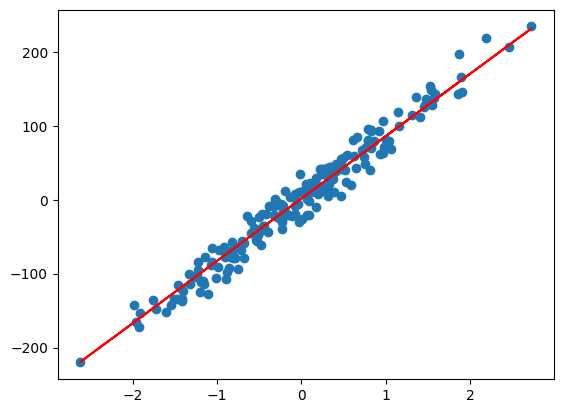

In [11]:
import matplotlib.pyplot as plt

with torch.no_grad():
    predictions = model(X_tensor)

plt.scatter(X, y)
plt.plot(X, predictions.numpy(), color="red")
plt.show()

In [12]:
from sklearn.datasets import make_classification
import numpy as np

X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    flip_y=0.1,  
    class_sep=0.8,  
    n_clusters_per_class=1,
    random_state=45,
)

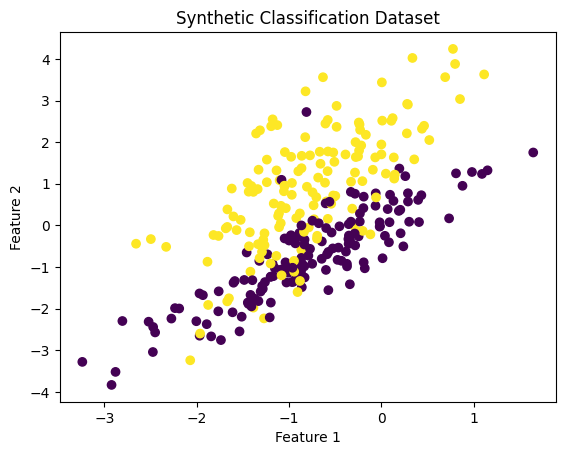

In [13]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Synthetic Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X, y)

predictions = model.predict(X)

In [15]:
print(model.__dict__)

{'penalty': 'l2', 'dual': False, 'tol': 0.0001, 'C': 1.0, 'fit_intercept': True, 'intercept_scaling': 1, 'class_weight': None, 'random_state': None, 'solver': 'lbfgs', 'max_iter': 100, 'multi_class': 'deprecated', 'verbose': 0, 'warm_start': False, 'n_jobs': None, 'l1_ratio': None, 'n_features_in_': 2, 'classes_': array([0, 1]), 'n_iter_': array([9], dtype=int32), 'coef_': array([[-2.27449188,  1.96806446]]), 'intercept_': array([-1.70766916])}


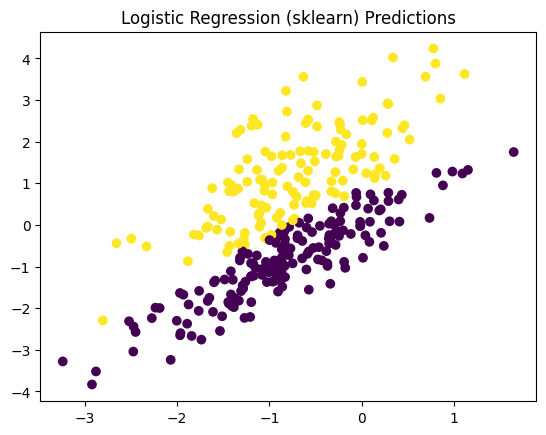

In [16]:
plt.scatter(X[:, 0], X[:, 1], c=predictions)
plt.title("Logistic Regression (sklearn) Predictions")
plt.show()

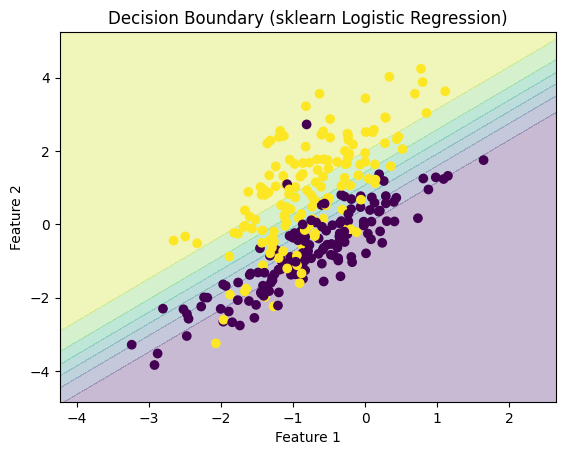

In [17]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200),
)

grid = np.c_[xx.ravel(), yy.ravel()]

probs = model.predict_proba(grid)[:, 1]

Z = probs.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X[:, 0], X[:, 1], c=y)

plt.title("Decision Boundary (sklearn Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [18]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [19]:
import torch.nn as nn

model = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())

In [20]:
criterion = nn.BCELoss()

In [21]:
import torch.optim as optim

optimizer = optim.SGD(model.parameters(), lr=0.1)

In [22]:
epochs = 300

for epoch in range(epochs):

    preds = model(X_tensor)

    loss = criterion(preds, y_tensor)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 50 == 0:
        print(epoch, loss.item())

0 0.9834908246994019
50 0.5111090540885925
100 0.4683379530906677
150 0.44625580310821533
200 0.43104198575019836
250 0.4199541211128235


In [23]:
with torch.no_grad():

    probs = model(X_tensor)

    predicted = (probs > 0.5).float()

In [24]:
print(predicted)

tensor([[0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
      

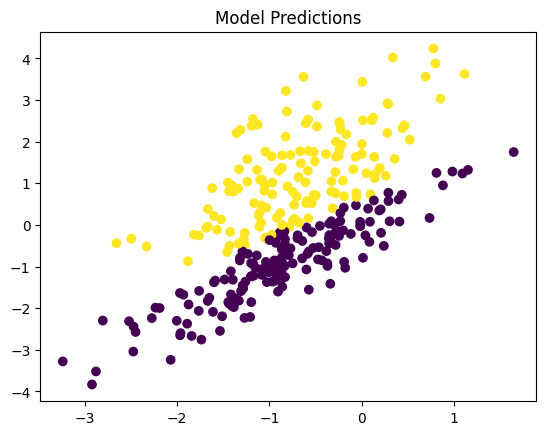

In [25]:
plt.scatter(X[:, 0], X[:, 1], c=predicted.numpy())
plt.title("Model Predictions")
plt.show()

In [26]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200),
)

grid = np.c_[xx.ravel(), yy.ravel()]

grid_tensor = torch.tensor(grid, dtype=torch.float32)

In [27]:
with torch.no_grad():
    probs = model(grid_tensor)

Z = probs.numpy().reshape(xx.shape)

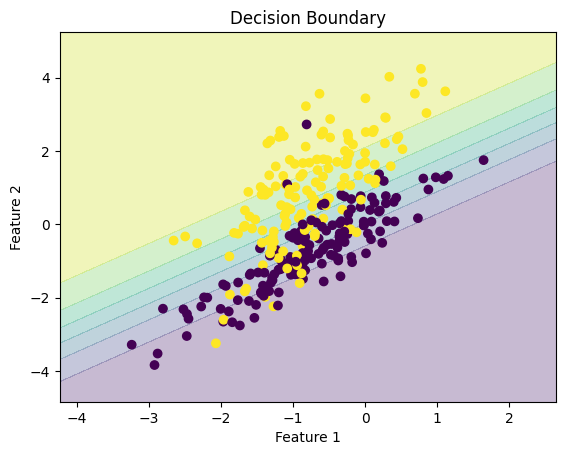

In [28]:
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X[:, 0], X[:, 1], c=y)

plt.title("Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

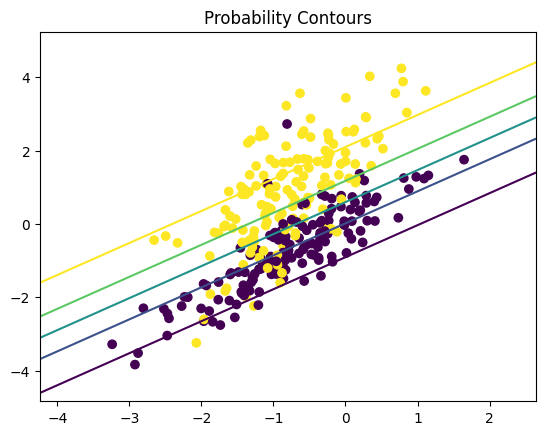

In [29]:
plt.contour(xx, yy, Z, levels=[0.1, 0.3, 0.5, 0.7, 0.9])

plt.scatter(X[:, 0], X[:, 1], c=y)

plt.title("Probability Contours")
plt.show()

In [30]:
print(model[0].weight)
print(model[0].bias)

Parameter containing:
tensor([[-1.2766,  1.4631]], requires_grad=True)
Parameter containing:
tensor([-0.8719], requires_grad=True)
